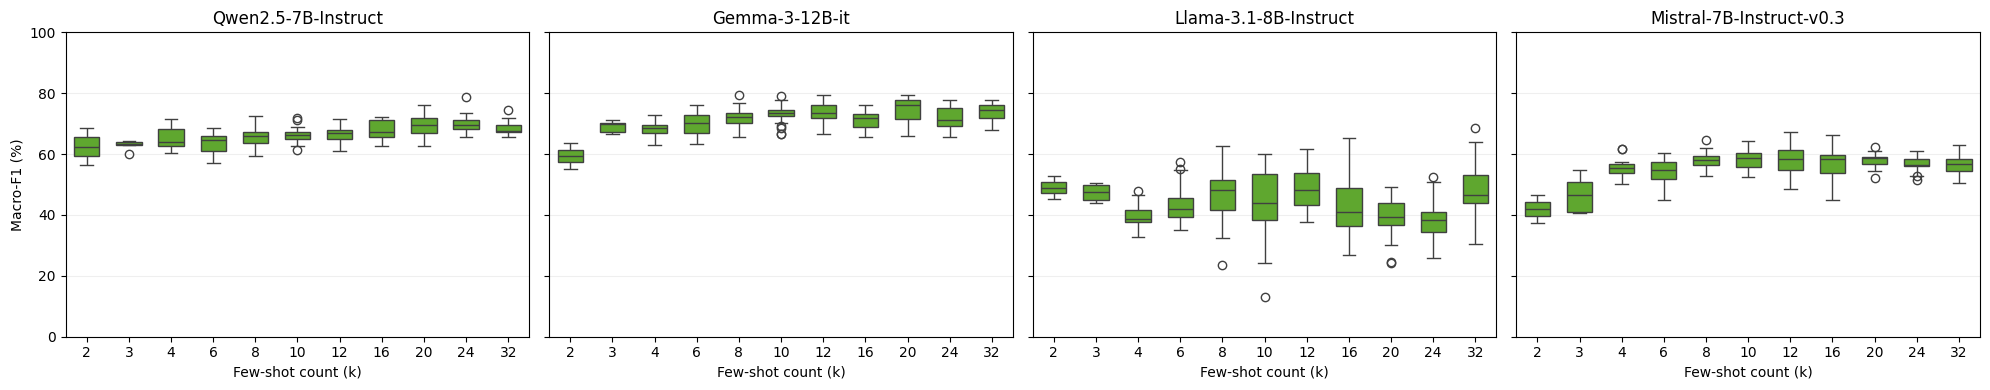

[SAVED] plots\random_order_strat_8B\macro_f1_dist_orders_vs_k_by_repo\facebook_react_macro_f1_dist_orders_vs_k_by_repo.pdf


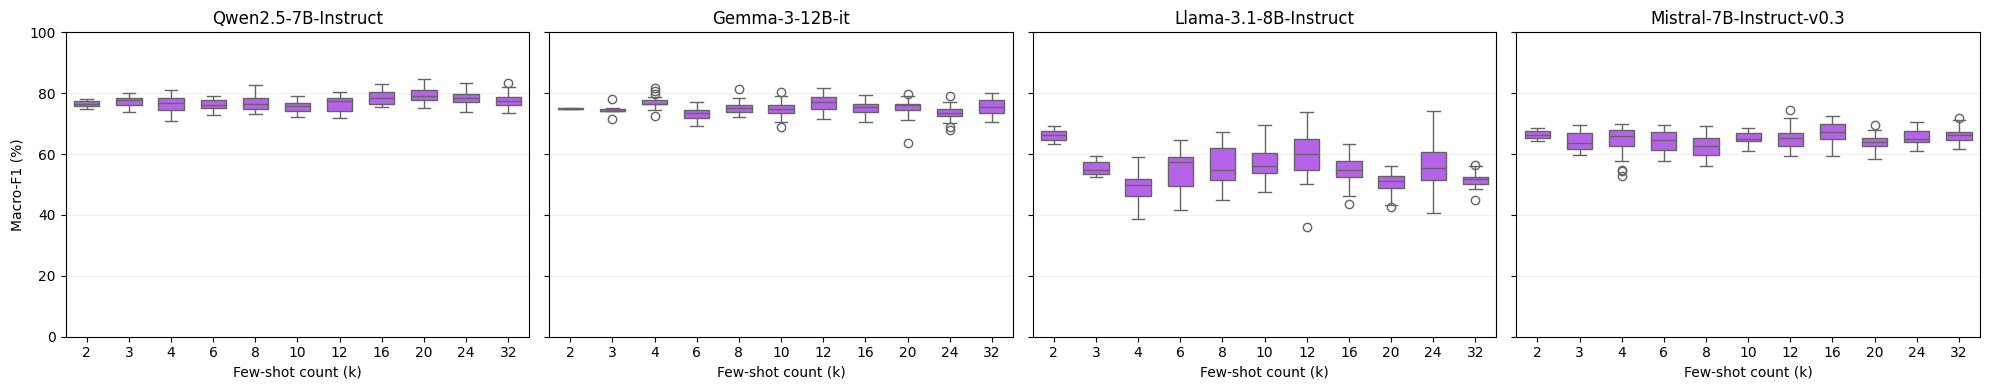

[SAVED] plots\random_order_strat_8B\macro_f1_dist_orders_vs_k_by_repo\bitcoin_bitcoin_macro_f1_dist_orders_vs_k_by_repo.pdf


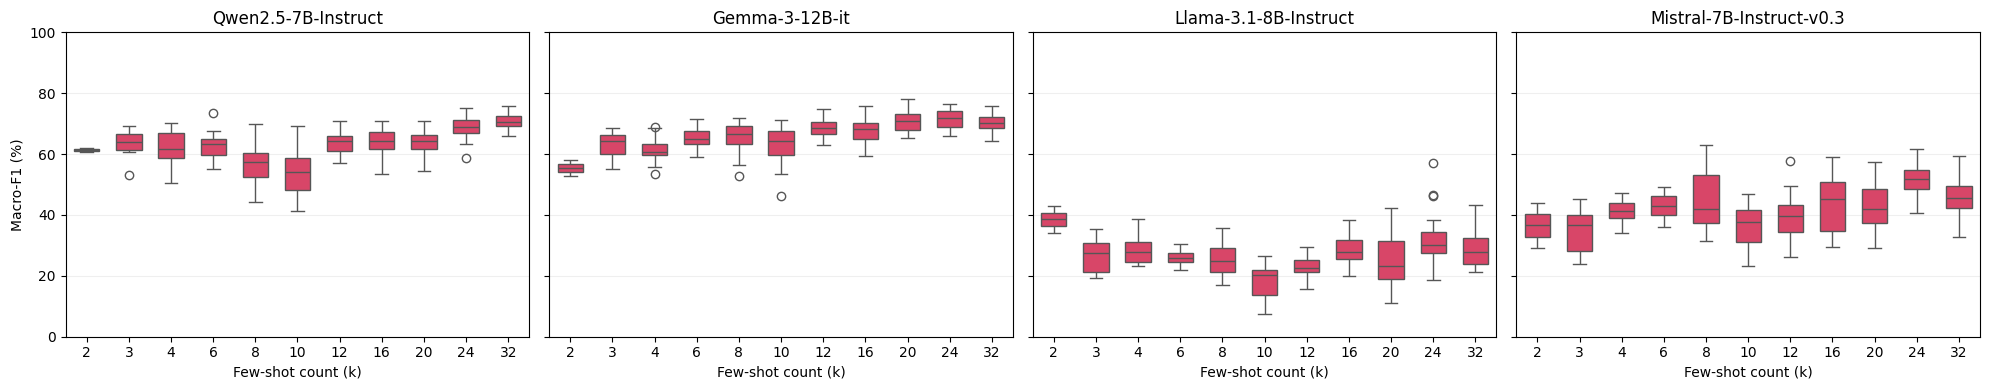

[SAVED] plots\random_order_strat_8B\macro_f1_dist_orders_vs_k_by_repo\opencv_opencv_macro_f1_dist_orders_vs_k_by_repo.pdf


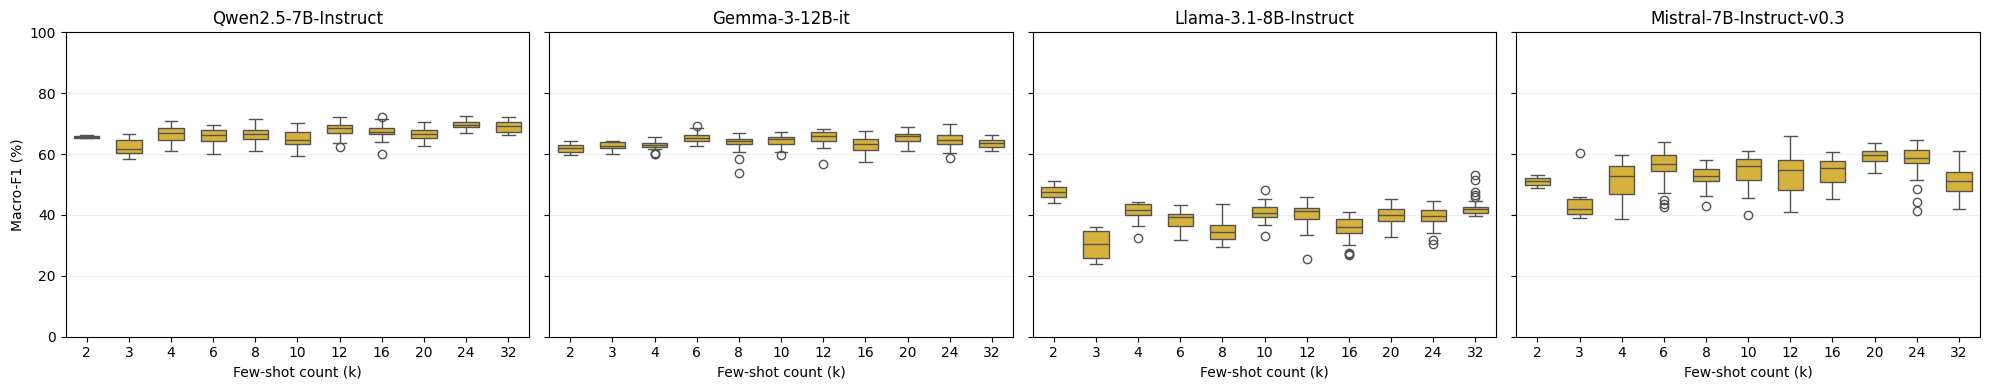

[SAVED] plots\random_order_strat_8B\macro_f1_dist_orders_vs_k_by_repo\tensorflow_tensorflow_macro_f1_dist_orders_vs_k_by_repo.pdf


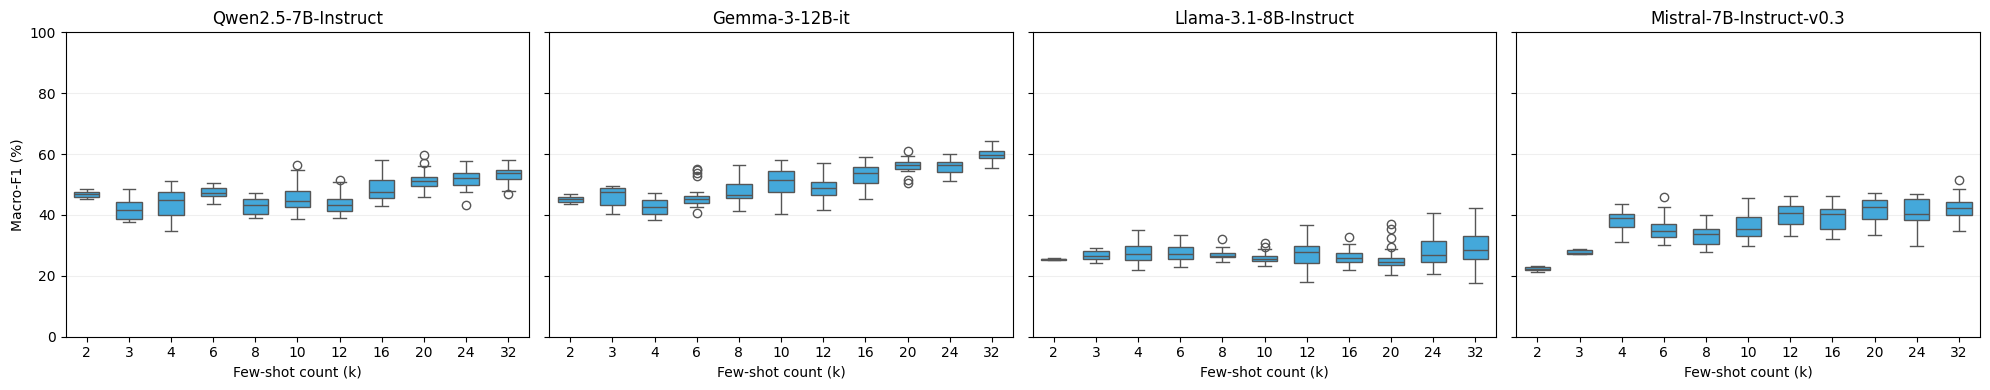

[SAVED] plots\random_order_strat_8B\macro_f1_dist_orders_vs_k_by_repo\microsoft_vscode_macro_f1_dist_orders_vs_k_by_repo.pdf


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ============================================================
# FORCE PURE MATPLOTLIB STYLE (MATCH TARGET FIGURE)
# ============================================================

plt.style.use("default")
plt.rcParams.update({
    "axes.facecolor": "white",
    "figure.facecolor": "white",
})

# ============================================================
# CONFIG
# ============================================================

BASE_DIR = Path("../rqs/random_order")

REPOS = [
    "facebook_react",
    "bitcoin_bitcoin",
    "opencv_opencv",
    "tensorflow_tensorflow",
    "microsoft_vscode",
]

MODELS = [
    "Qwen/Qwen2.5-7B-Instruct",
    "google/gemma-3-12b-it",
    "meta-llama/Llama-3.1-8B-Instruct",
    "mistralai/Mistral-7B-Instruct-v0.3",
]

model_display_name = {
    "google/gemma-3-12b-it": "Gemma-3-12B-it",
    "meta-llama/Llama-3.1-8B-Instruct": "Llama-3.1-8B-Instruct",
    "mistralai/Mistral-7B-Instruct-v0.3": "Mistral-7B-Instruct-v0.3",
    "Qwen/Qwen2.5-7B-Instruct": "Qwen2.5-7B-Instruct",
}

FEWSHOT_ORDER = [2, 3, 4, 6, 8, 10, 12, 16, 20, 24, 32]

repo_color_map = {
    "facebook_react": "#5BBB1B",
    "bitcoin_bitcoin": "#BB4DFF",
    "opencv_opencv": "#F12D5B",
    "tensorflow_tensorflow": "#F0C023",
    "microsoft_vscode": "#2BB0F3",
}

OUTPUT_DIR = Path("plots/random_order/macro_f1_dist_orders_vs_k_by_repo")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# DATA LOADING
# ============================================================

def load_shuffle_data():
    all_rows = []

    for repo in REPOS:
        for model in MODELS:

            provider, model_name = model.split("/", 1)

            csv_path = (
                BASE_DIR
                / repo
                / "models"
                / provider
                / model_name
                / "logs"
                / "order_permutation_results_macro_f1.csv"
            )

            if not csv_path.exists():
                print(f"[WARN] Missing: {csv_path}")
                continue

            df = pd.read_csv(csv_path)

            # shuffled order results
            shuffled = df[[
                "Repo",
                "FewShot_Count",
                "Shuffled_Macro_F1"
            ]].rename(columns={"Shuffled_Macro_F1": "Macro_F1"})

            # original prompt order
            original = (
                df[[
                    "Repo",
                    "FewShot_Count",
                    "Original_Macro_F1"
                ]]
                .drop_duplicates()
                .rename(columns={"Original_Macro_F1": "Macro_F1"})
            )

            combined = pd.concat([shuffled, original], ignore_index=True)

            # convert to %
            combined["Macro_F1_pct"] = combined["Macro_F1"] * 100

            combined["Repo"] = repo
            combined["Model"] = model

            all_rows.append(combined)

    return pd.concat(all_rows, ignore_index=True)


data = load_shuffle_data()
data = data[data["FewShot_Count"].isin(FEWSHOT_ORDER)]

# ============================================================
# PLOTTING
# ============================================================

for repo in REPOS:

    df_repo = data[data["Repo"] == repo].copy()

    # enforce categorical order for k
    df_repo["FewShot_Count"] = pd.Categorical(
        df_repo["FewShot_Count"],
        categories=FEWSHOT_ORDER,
        ordered=True
    )

    fig, axes = plt.subplots(
        nrows=1,
        ncols=len(MODELS),
        figsize=(5 * len(MODELS), 4),
        sharey=True
    )

    repo_color = repo_color_map[repo]

    for ax, model in zip(axes, MODELS):

        df_m = df_repo[df_repo["Model"] == model]

        if df_m.empty:
            ax.axis("off")
            continue

        sns.boxplot(
            data=df_m,
            x="FewShot_Count",
            y="Macro_F1_pct",
            ax=ax,
            color=repo_color,
            showfliers=True,
            width=0.6,
            linewidth=1
        )

        ax.set_title(model_display_name.get(model, model))
        ax.set_xlabel("Few-shot count (k)")
        ax.grid(True, axis="y", alpha=0.2)

    axes[0].set_ylabel("Macro-F1 (%)")
    axes[0].set_ylim(0, 100)

    plt.tight_layout()

    output_path = OUTPUT_DIR / f"{repo}_macro_f1_dist_orders_vs_k_by_repo.pdf"
    plt.savefig(output_path, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"[SAVED] {output_path}")